# VKR — основной ноутбук

Ноутбук использует пакет `src/`. Вся логика (препроцессинг, методы, агрегация, графики, статистика) — в файлах. Здесь только запуск и просмотр.

См. `README.md` в корне проекта для полной инструкции.

## 1. Импорты и настройка

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: c:\Users\16052\Documents\ВМК\Научная Работа\Диплом\vkr_project_V2\vkr


In [2]:
from src.config import CONFIG, SEEDS, device, RESULTS_DIR
from src.data import DATASETS, load_datasets
from src.methods import METHODS, HPO_METHODS, DE_METHODS
from src.runner import run_all
from src.aggregation import aggregate_results, print_table
from src.plots import plot_convergence_unified, plot_convergence_all_axes, plot_bar_comparison
from src.stats import run_full_statistical_analysis

print(f"Device: {device}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Seeds: {SEEDS}")
print(f"\nHPO методы (Класс A): {list(HPO_METHODS.keys())}")
print(f"DE методы (Класс B): {list(DE_METHODS.keys())}")
print(f"Датасеты: {list(DATASETS.keys())}")

Device: cuda
Results dir: results_fixed
Seeds: [42, 123, 2024, 7, 999]

HPO методы (Класс A): ['Adam_baseline', 'Adam_RandomSearch', 'Adam_TPE', 'Adam_GP_BO', 'Adam_Hyperband', 'Adam_BOHB', 'Adam_MFBO']
DE методы (Класс B): ['Baseline_DE', 'Optuna_DE', 'DE_DE_Hybrid']
Датасеты: ['wine', 'wdbc', 'digits', 'abalone', 'kin8nm', 'higgs', 'cifar10', 'fashion_mnist']


## 2. Просмотр конфигурации

Все параметры — в `src/config.py`. Менять там, не в ноутбуке.

In [3]:
import json
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

{
  "split": {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
  },
  "batch_size": 64,
  "num_workers": 0,
  "adam_baseline": {
    "hidden_dim": 256,
    "lr": 0.001,
    "dropout": 0.2,
    "epochs": 50
  },
  "adam_optuna": {
    "n_trials": 15,
    "search_epochs": 10,
    "final_epochs": 20,
    "h_range": [
      128,
      512
    ],
    "lr_range": [
      0.0001,
      0.005
    ],
    "dropout_range": [
      0.0,
      0.5
    ]
  },
  "baseline_de": {
    "hidden_dim": 256,
    "n_pop": 40,
    "n_gen": 60,
    "F": 0.6,
    "Cr": 0.9,
    "bounds": [
      -0.5,
      0.5
    ],
    "max_seconds_per_run": 600
  },
  "optuna_de": {
    "n_trials": 5,
    "inner_pop": 25,
    "inner_gen": 20,
    "final_pop": 40,
    "final_gen": 60,
    "F": 0.6,
    "Cr": 0.9,
    "bounds": [
      -0.5,
      0.5
    ],
    "h_range": [
      128,
      400
    ],
    "max_seconds_per_run": 1200
  },
  "de_de_hybrid": {
    "outer_pop": 6,
    "outer_gen": 6,
    "inner_pop": 20,
   

## 3. Запуск экспериментов

`skip_existing=True` пропускает уже посчитанные `(dataset, method, seed)` — удобно для дозапусков.

### 3.1. Smoke-тест: один метод, один датасет, один seed

In [ ]:
# run_all(
#     seeds=[42],
#     methods=["Adam_baseline"],
#     datasets=["wine"],
# )

### 3.2. HPO-методы на малых tabular

Все 7 методов класса A на 5 малых датасетах × 5 seeds. Самое быстрое — несколько часов на RTX 4060.

In [ ]:
# run_all(
#     methods=list(HPO_METHODS.keys()),
#     datasets=["wine", "wdbc", "digits", "abalone", "kin8nm"],
#     skip_existing=True,
# )

### 3.3. DE-методы (отдельный подраздел диплома)

Только на tabular датасетах. На image не запускаются (защита в runner).

In [4]:
import os, json
from pathlib import Path

results = Path("results_fixed")
broken = []
for ds_dir in results.iterdir():
    if not ds_dir.is_dir(): continue
    for method_dir in ds_dir.iterdir():
        if not method_dir.is_dir(): continue
        for seed_dir in method_dir.iterdir():
            if not seed_dir.is_dir(): continue
            meta = seed_dir / "meta.json"
            traj = seed_dir / "trajectory.json"
            ckpt = seed_dir / "checkpoint.pt"
            if not meta.exists():
                broken.append((seed_dir, "no meta.json"))
            elif not traj.exists():
                broken.append((seed_dir, "no trajectory.json"))
            elif not ckpt.exists():
                broken.append((seed_dir, "no checkpoint.pt"))
            else:
                # Проверим, что meta.json валидный
                try:
                    with open(meta) as f:
                        json.load(f)
                except json.JSONDecodeError:
                    broken.append((seed_dir, "broken meta.json"))

print(f"Битых папок: {len(broken)}")
for path, reason in broken:
    print(f"  {path}: {reason}")

Битых папок: 46
  results_fixed\abalone\Adam_Optuna\seed_123: no trajectory.json
  results_fixed\abalone\Adam_Optuna\seed_2024: no trajectory.json
  results_fixed\abalone\Adam_Optuna\seed_42: no trajectory.json
  results_fixed\abalone\Adam_Optuna\seed_7: no trajectory.json
  results_fixed\abalone\Adam_Optuna\seed_999: no trajectory.json
  results_fixed\abalone\Baseline_DE\seed_7: no trajectory.json
  results_fixed\abalone\Baseline_DE\seed_999: no trajectory.json
  results_fixed\abalone\DE_DE_Hybrid\seed_7: no trajectory.json
  results_fixed\abalone\DE_DE_Hybrid\seed_999: no trajectory.json
  results_fixed\abalone\Optuna_DE\seed_7: no trajectory.json
  results_fixed\abalone\Optuna_DE\seed_999: no trajectory.json
  results_fixed\digits\Adam_Optuna\seed_123: no trajectory.json
  results_fixed\digits\Adam_Optuna\seed_2024: no trajectory.json
  results_fixed\digits\Adam_Optuna\seed_42: no trajectory.json
  results_fixed\digits\Adam_Optuna\seed_7: no trajectory.json
  results_fixed\digits\Ad

In [5]:
import shutil
for path, _ in broken:
    print(f"Удаляю {path}")
    shutil.rmtree(path)

Удаляю results_fixed\abalone\Adam_Optuna\seed_123
Удаляю results_fixed\abalone\Adam_Optuna\seed_2024
Удаляю results_fixed\abalone\Adam_Optuna\seed_42
Удаляю results_fixed\abalone\Adam_Optuna\seed_7
Удаляю results_fixed\abalone\Adam_Optuna\seed_999
Удаляю results_fixed\abalone\Baseline_DE\seed_7
Удаляю results_fixed\abalone\Baseline_DE\seed_999
Удаляю results_fixed\abalone\DE_DE_Hybrid\seed_7
Удаляю results_fixed\abalone\DE_DE_Hybrid\seed_999
Удаляю results_fixed\abalone\Optuna_DE\seed_7
Удаляю results_fixed\abalone\Optuna_DE\seed_999
Удаляю results_fixed\digits\Adam_Optuna\seed_123
Удаляю results_fixed\digits\Adam_Optuna\seed_2024
Удаляю results_fixed\digits\Adam_Optuna\seed_42
Удаляю results_fixed\digits\Adam_Optuna\seed_7
Удаляю results_fixed\digits\Adam_Optuna\seed_999
Удаляю results_fixed\kin8nm\Adam_Optuna\seed_123
Удаляю results_fixed\kin8nm\Adam_Optuna\seed_2024
Удаляю results_fixed\kin8nm\Adam_Optuna\seed_42
Удаляю results_fixed\kin8nm\Adam_Optuna\seed_7
Удаляю results_fixed\ki

In [6]:
run_all(
    methods=list(DE_METHODS.keys()),
    datasets=["wine", "wdbc", "digits", "abalone", "kin8nm"],
    skip_existing=True,
)


DATASET: wine  (kind=tabular, task=classification)

--- seed 42 ---
Shape: in=13 out=3 n_tr=124 n_val=27 n_test=27
  [Baseline_DE] skip (already exists)
  [Optuna_DE] skip (already exists)
  [DE_DE_Hybrid] skip (already exists)

--- seed 123 ---
Shape: in=13 out=3 n_tr=124 n_val=27 n_test=27
  [Baseline_DE] skip (already exists)
  [Optuna_DE] skip (already exists)
  [DE_DE_Hybrid] skip (already exists)

--- seed 2024 ---
Shape: in=13 out=3 n_tr=124 n_val=27 n_test=27
  [Baseline_DE] skip (already exists)
  [Optuna_DE] skip (already exists)
  [DE_DE_Hybrid] skip (already exists)

--- seed 7 ---
Shape: in=13 out=3 n_tr=124 n_val=27 n_test=27
  [Baseline_DE] skip (already exists)
  [Optuna_DE] skip (already exists)
  [DE_DE_Hybrid] skip (already exists)

--- seed 999 ---
Shape: in=13 out=3 n_tr=124 n_val=27 n_test=27
  [Baseline_DE] skip (already exists)
  [Optuna_DE] skip (already exists)
  [DE_DE_Hybrid] skip (already exists)

DATASET: wdbc  (kind=tabular, task=classification)

--- see

Baseline DE:   0%|          | 0/60 [00:00<?, ?it/s]

loss=0.5700 r2=0.5003 [26.9s]
  [Optuna_DE] ... 

[I 2026-05-03 18:53:15,000] A new study created in memory with name: no-name-763c4a86-9f97-4287-87c7-a5c7010d720c


Optuna-DE trial 0:   0%|          | 0/20 [00:00<?, ?it/s]

...

Inner DE:   0%|          | 0/20 [00:00<?, ?it/s]

Inner DE:   0%|          | 0/20 [00:00<?, ?it/s]

Inner DE:   0%|          | 0/20 [00:00<?, ?it/s]

Final inner DE:   0%|          | 0/20 [00:00<?, ?it/s]

loss=0.9655 r2=0.0570 [440.8s]


### 3.4. Большие датасеты — на A100

Higgs и CIFAR-10. Здесь MFBO должен показать преимущество. Долго — заранее планируйте бюджет A100-времени.

In [ ]:
# run_all(
#     methods=list(HPO_METHODS.keys()),
#     datasets=["higgs", "cifar10"],
#     seeds=[42, 123, 2024],   # 3 seeds для Higgs/CIFAR
#     skip_existing=True,
# )

### 3.5. Полный запуск всего

Можно дать одной командой, run_all сам пройдёт по всему. Но лучше делить, чтобы контролировать прогресс.

In [ ]:
# run_all(skip_existing=True)

## 4. Агрегация результатов

In [7]:
df, histories, trajectories = aggregate_results()
print_table(df)


=== Test Loss (mean ± std по seeds) ===
╒═══════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│ Dataset   │ Adam_baseline          │ Adam_RandomSearch      │ Adam_TPE               │ Adam_GP_BO             │ Adam_Hyperband         │ Adam_BOHB              │ Adam_MFBO              │ Baseline_DE            │ Optuna_DE              │ DE_DE_Hybrid           │
╞═══════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ WINE      │ 0.0786 ± 0.0804  (n=5) │ 0.1050 ± 0.1625  (n=5) │ 0.1324 ± 0.0879  (n=5) │ 0.1654 ± 0.1851  (n=5) │ 0.2227 ± 0.2120  (n=5) │ 0.1626 ± 0.2566  (n=5) │ 0.1

## 5. Графики сходимости

Три варианта оси X: wall-clock, число full evaluations, эпохи-эквиваленты.

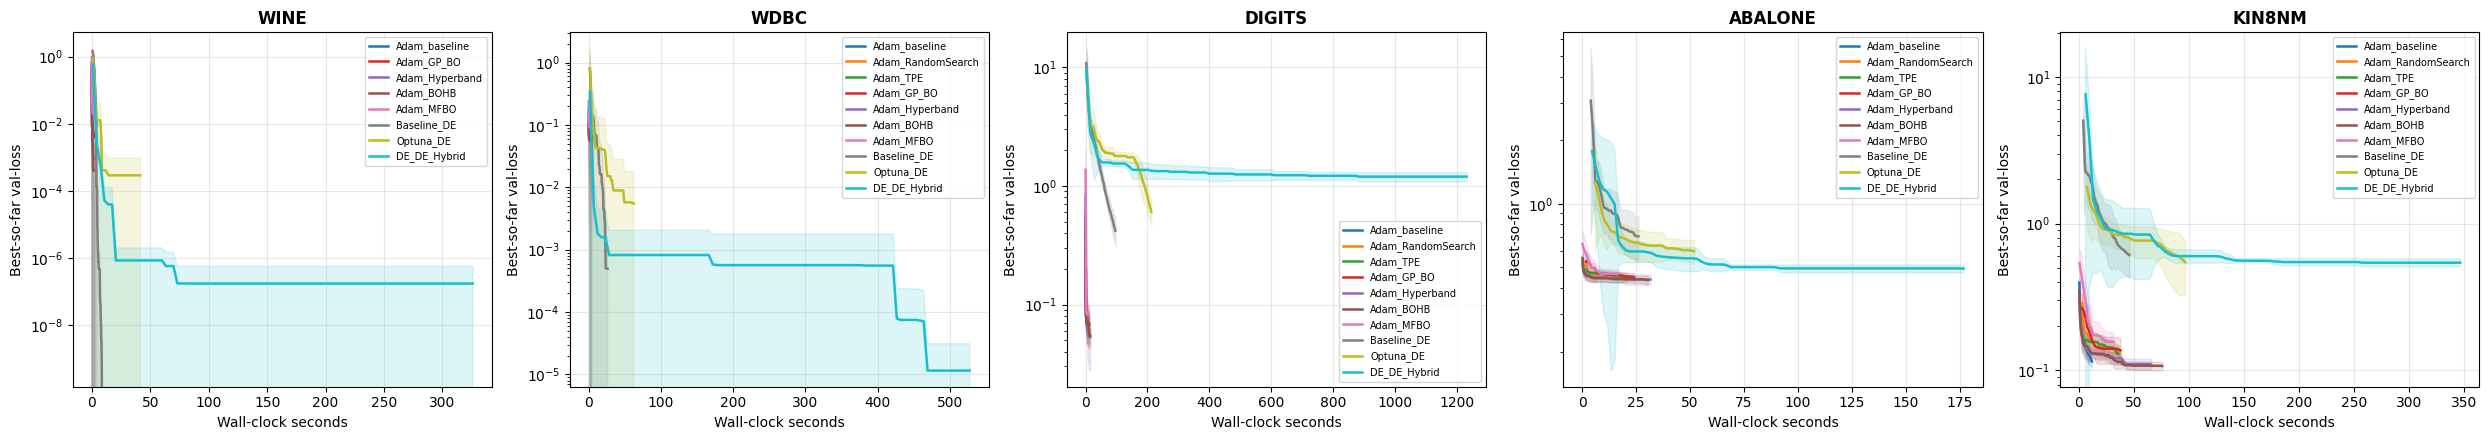

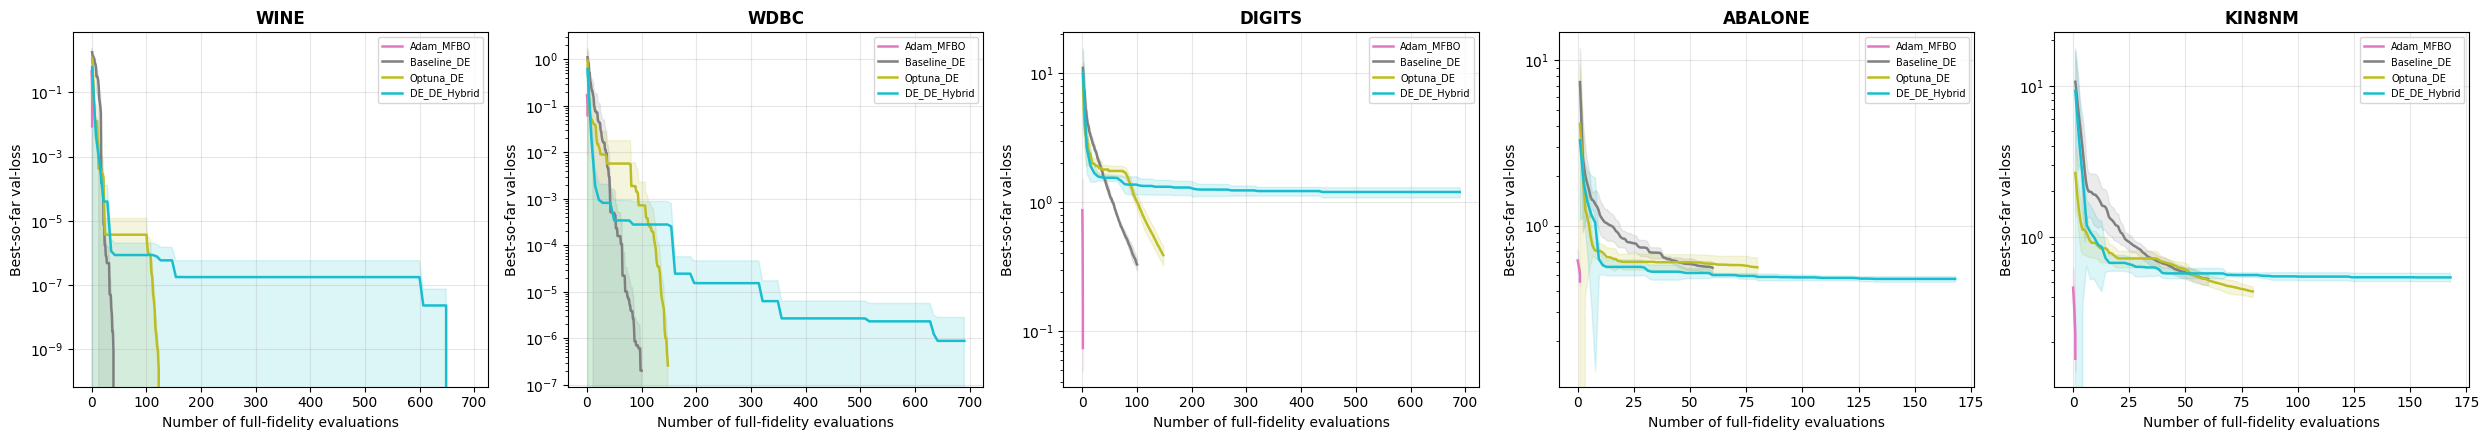

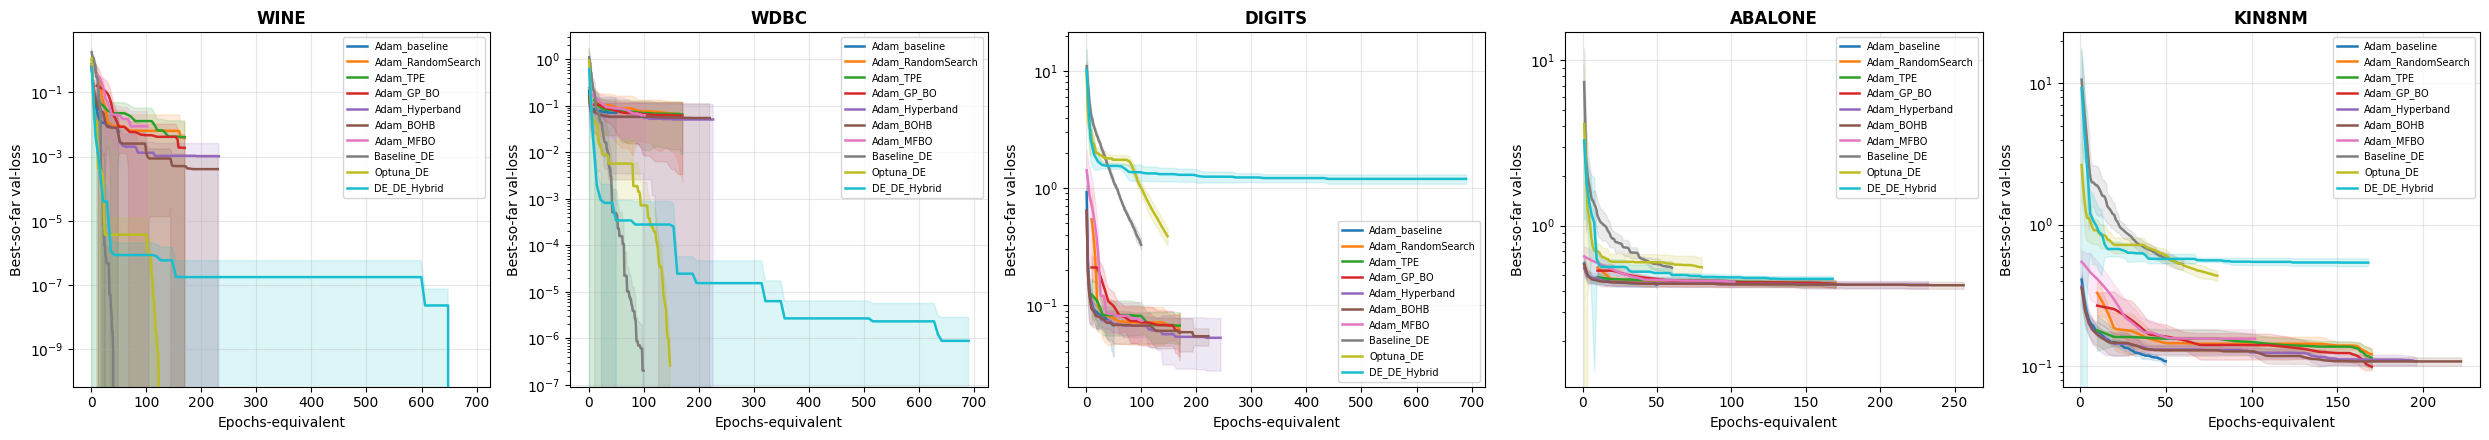

In [8]:
plot_convergence_all_axes(trajectories)

Если нужен только один из вариантов:

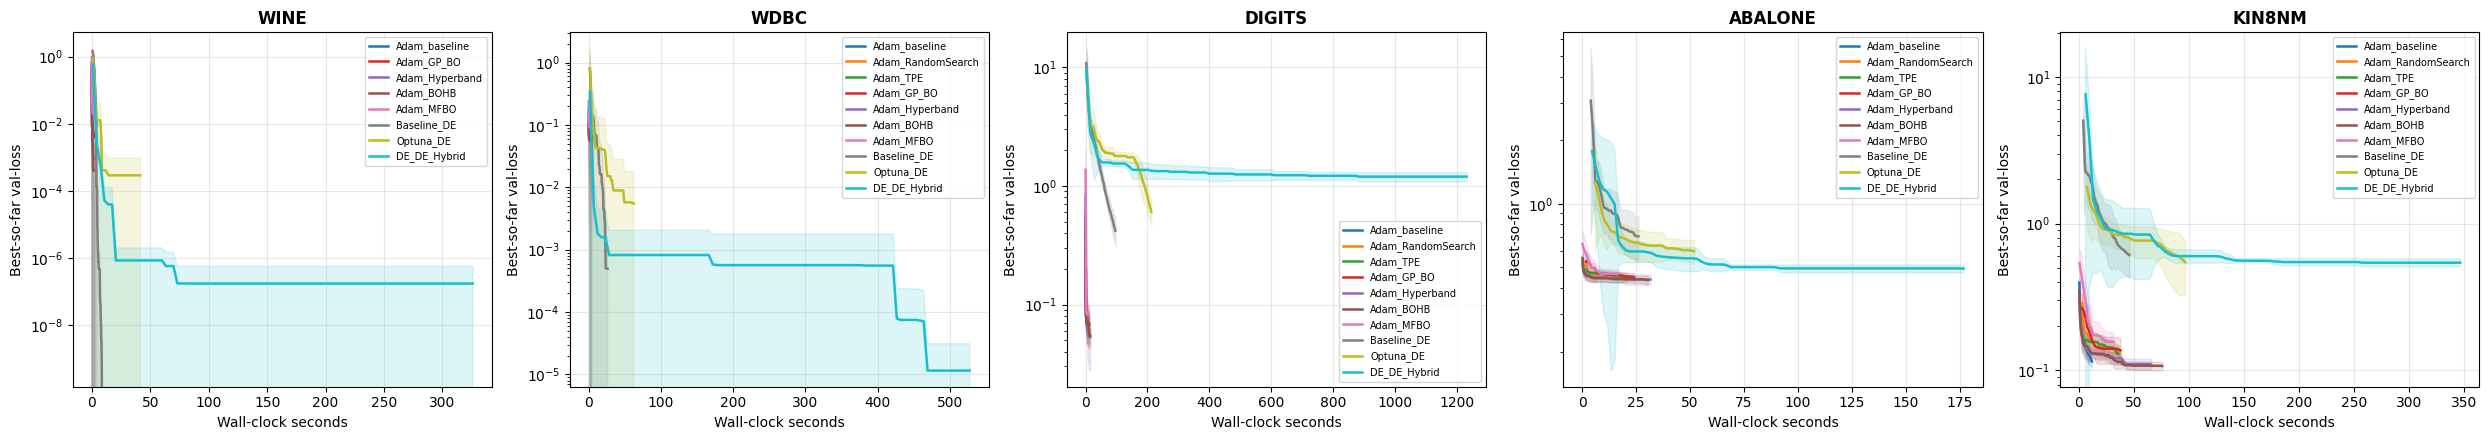

In [9]:
plot_convergence_unified(trajectories, x_key="time")

## 6. Сравнение методов на тесте — barplot

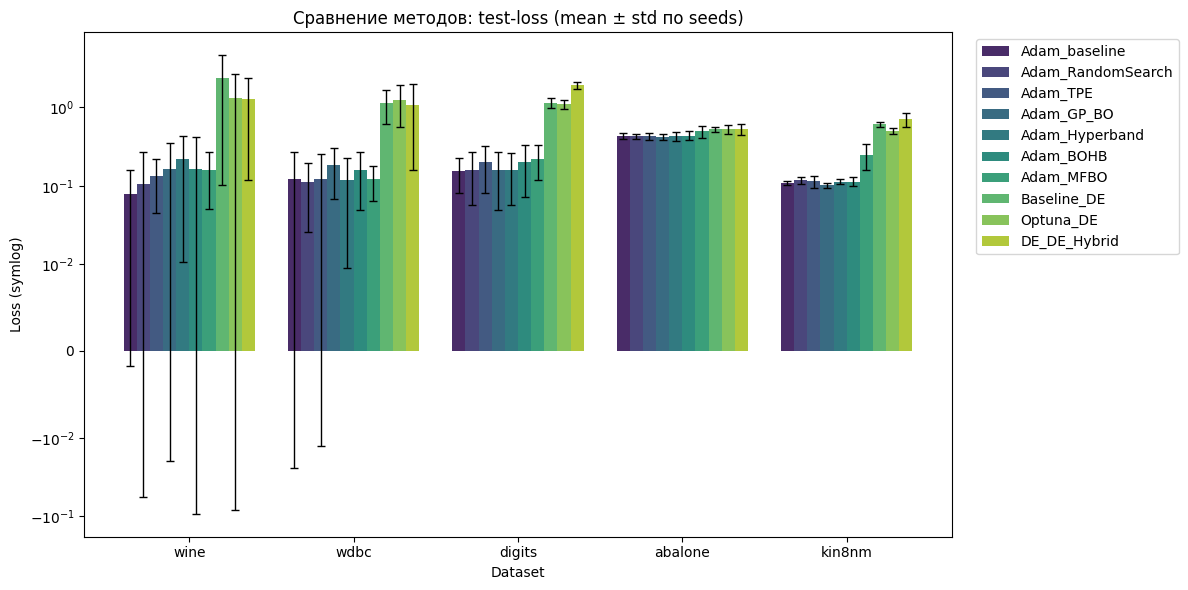

In [10]:
plot_bar_comparison(df)

## 7. Статистический анализ

Friedman + Nemenyi + Critical Difference diagram.
Единица анализа — датасет (не seed), согласно Demšar 2006.

=== Friedman test на матрице 5 датасетов × 10 методов ===
χ² = 32.5200, p-value = 0.0002
H0 отвергается на уровне α=0.05: между методами есть значимые различия

Средние ранги (1 = лучший):
method
Adam_baseline        2.8
Adam_GP_BO           3.4
Adam_RandomSearch    3.4
Adam_Hyperband       3.6
Adam_TPE             3.8
Adam_BOHB            5.2
Adam_MFBO            5.8
Optuna_DE            8.8
Baseline_DE          9.0
DE_DE_Hybrid         9.2

Critical Difference (Nemenyi, α=0.05): 6.0586


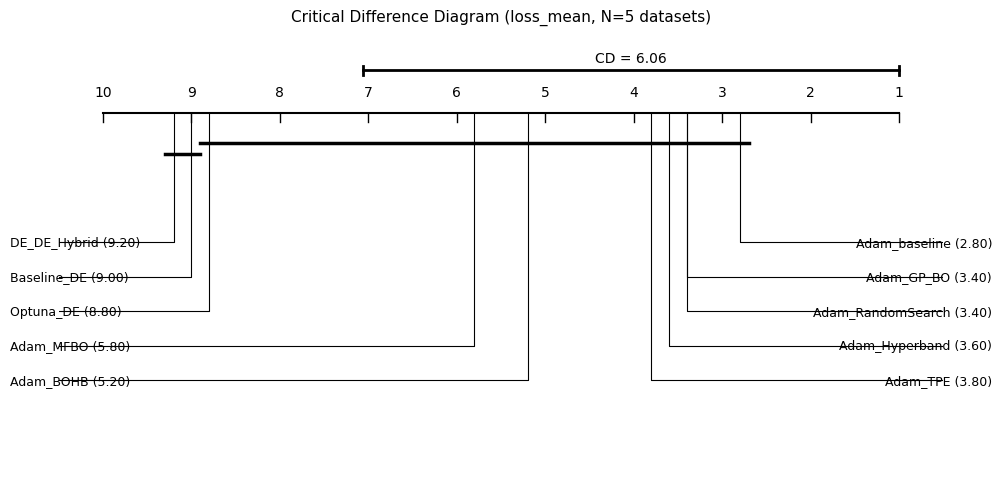

In [11]:
results = run_full_statistical_analysis(df, metric="loss_mean", lower_is_better=True,
                                       save_dir=RESULTS_DIR)

Можно сравнить только HPO-методы между собой (исключив DE):

=== Friedman test на матрице 5 датасетов × 7 методов ===
χ² = 7.5429, p-value = 0.2735
H0 не отвергается на уровне α=0.05: значимых различий нет

Средние ранги (1 = лучший):
method
Adam_baseline        2.8
Adam_GP_BO           3.4
Adam_RandomSearch    3.4
Adam_Hyperband       3.6
Adam_TPE             3.8
Adam_BOHB            5.2
Adam_MFBO            5.8

Critical Difference (Nemenyi, α=0.05): 4.0291


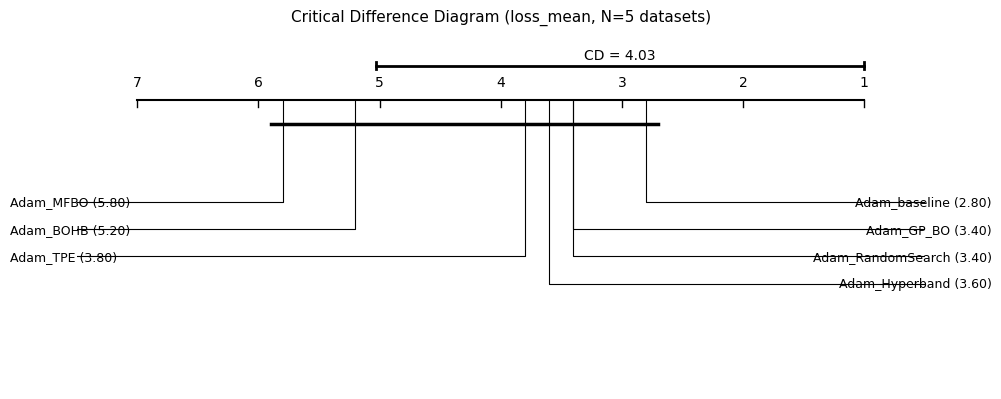

In [12]:
df_hpo = df[df["method"].isin(HPO_METHODS.keys())]
results_hpo = run_full_statistical_analysis(df_hpo, metric="loss_mean", save_dir=RESULTS_DIR)